In [1]:
import glob
import json
import os.path
from os.path import basename

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import f1_score

In [2]:
exp001a_paths = [
    "../../logs/exp001/exp001a/sweep-2025-07-30_14-11-25_test_eval_recordings/0/usleep_test_results.json",
    "../../logs/exp001/exp001a/sweep-2025-07-30_14-11-25_test_eval_recordings/1/usleep_test_results.json",
    "../../logs/exp001/exp001a/sweep-2025-07-30_14-11-25_test_eval_recordings/2/usleep_test_results.json",
]
exp002a_paths = [
    "../../logs/exp002/exp002a/sweep-2025-07-30_13-56-48_test_eval_recordings/0/anysleep_test_results.json",
    "../../logs/exp002/exp002a/sweep-2025-07-30_13-56-48_test_eval_recordings/1/anysleep_test_results.json",
    "../../logs/exp002/exp002a/sweep-2025-07-30_13-56-48_test_eval_recordings/2/anysleep_test_results.json",
]

stages = ["Wake", "N1", "N2", "N3", "REM"]
id_datasets = [
    "abc",
    "ccshs",
    "cfs",
    "chat",
    "dcsm",
    "hpap",
    "mesa",
    "mros",
    "phys",
    "sedf-sc",
    "sedf-st",
    "shhs",
    "sof",
]
ood_datasets = [
    "dodh",
    "dodo",
    "isruc-sg1",
    "isruc-sg2",
    "isruc-sg3",
    "mass-c1",
    "mass-c3",
    "svuh",
]

exp001a_rec_scores = []
exp001a_dod_scores = {"dodo": [], "dodh": []}
for path in exp001a_paths:
    with open(path, "r") as f:
        exp001a = json.load(f)
    for dataset, recordings in exp001a["recordings"].items():
        for recording, scores in recordings.items():
            score = scores["majority"]
            exp001a_rec_scores.append(
                np.mean([score[stage]["f1"][0] for stage in stages])
            )

            if dataset == "dodh":
                exp001a_dod_scores["dodh"].append(
                    np.mean([score[stage]["f1"][0] for stage in stages])
                )
            elif dataset == "dodo":
                exp001a_dod_scores["dodo"].append(
                    np.mean([score[stage]["f1"][0] for stage in stages])
                )

exp002a_rec_scores_id = []
exp002a_rec_scores_ood = []
exp002a_dod_scores = {"dodo": [], "dodh": []}
for path in exp002a_paths:
    with open(path, "r") as f:
        exp002a = json.load(f)
    for dataset, recordings in exp002a["recordings"].items():
        for recording, scores in recordings.items():
            assert len(scores) == 1
            for channel, score in scores.items():
                if dataset in id_datasets:
                    exp002a_rec_scores_id.append(
                        np.mean([score[stage]["f1"][0] for stage in stages])
                    )
                elif dataset in ood_datasets:
                    exp002a_rec_scores_ood.append(
                        np.mean([score[stage]["f1"][0] for stage in stages])
                    )
                else:
                    raise ValueError()

                if dataset == "dodh":
                    exp002a_dod_scores["dodh"].append(
                        np.mean([score[stage]["f1"][0] for stage in stages])
                    )
                elif dataset == "dodo":
                    exp002a_dod_scores["dodo"].append(
                        np.mean([score[stage]["f1"][0] for stage in stages])
                    )

In [3]:
# FIXME: configure this based on your save location
dod_path = os.path.expanduser("<path-to-dod-scorers-repo>/dreem-learning-evaluation/scorers/")
scorers = [f"scorer_{i}" for i in range(1, 6)]
NOT_SCORED = -1
f1_scores_dod = {}

for data_subset in ["dodh", "dodo"]:
    recordings = glob.glob(os.path.join(dod_path, data_subset, scorers[0], "*.json"))
    for rec in recordings:
        s_id = basename(rec)[:-5]
        f1_scores_dod[s_id] = {}

        # remove annotations that have not been scored by all scorers
        scores = {}
        for scorer in scorers:
            sta_file = os.path.join(dod_path, data_subset, scorer, basename(rec))
            with open(sta_file) as sf:
                scores[scorer] = np.array(json.load(sf))
        index_min = np.max([np.where(s != NOT_SCORED)[0][0] for s in scores.values()])
        index_max = len(scores[scorers[0]]) - np.max(
            [np.where(s[::-1] != NOT_SCORED)[0][0] for s in scores.values()]
        )
        scores = {k: v[index_min:index_max] for k, v in scores.items()}

        # pairwise comparison of scorers
        for i, scorer1 in enumerate(scorers):
            for scorer2 in scorers[i + 1:]:
                f1 = f1_score(scores[scorer1], scores[scorer2], average="macro")
                f1_scores_dod[s_id][f"{scorer1}-{scorer2}"] = f1

Std of expert pairs: 0.12
Quartiles of expert pairs: [0.58936752 0.6852025  0.76209615]
Percentage of expert pairs with F1 < 0.5: 8.75%


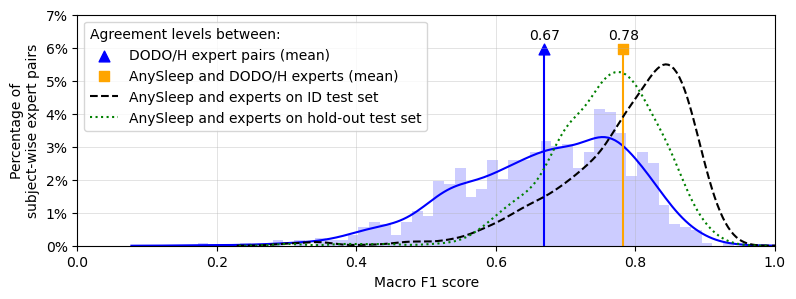

In [4]:
recs = [rec for rec in f1_scores_dod]
data_to_plot = [
    f1_scores_dod[rec][f"{scorer1}-{scorer2}"]
    for i, scorer1 in enumerate(scorers)
    for scorer2 in scorers[i + 1:]
    for rec in recs
]
data_to_plot = np.array(data_to_plot)

plt.figure(figsize=(9, 3))
plt.hist(data_to_plot, bins=50, alpha=0.2, density=True, color="blue")
sns.kdeplot(data_to_plot, color="blue")

max_y = plt.ylim()[1]
plt.vlines(
    np.mean(data_to_plot),
    0,
    max_y + 1.6,
    linestyles="-",
    color="blue",
)
plt.text(
    np.mean(data_to_plot),
    max_y + 1.8,
    f"{np.mean(data_to_plot):.2f}",
    verticalalignment="bottom",
    horizontalalignment="center",
)
plt.scatter(
    np.mean(data_to_plot),
    max_y + 1.6,
    color="blue",
    marker="^",
    s=60,
    label="DODO/H expert pairs (mean)",
)
print(f"Std of expert pairs: {np.std(data_to_plot):.2f}")
print(f"Quartiles of expert pairs: {np.quantile(data_to_plot, [0.25, 0.5, 0.75])}")
print(
    f"Percentage of expert pairs with F1 < 0.5: {np.sum(data_to_plot < 0.5) / len(data_to_plot) * 100:.2f}%"
)

dod_mean = np.mean(np.concat(list(exp002a_dod_scores.values())))
plt.vlines(
    dod_mean,
    0,
    max_y + 1.6,
    color="orange",
)
plt.text(
    dod_mean,
    max_y + 1.8,
    f"{dod_mean:.2f}",
    verticalalignment="bottom",
    horizontalalignment="center",
)
plt.scatter(
    dod_mean,
    max_y + 1.6,
    color="orange",
    marker="s",
    s=60,
    label="AnySleep and DODO/H experts (mean)",
)

sns.kdeplot(
    exp002a_rec_scores_id,
    color="black",
    ls="--",
    label="AnySleep and experts on ID test set",
)

sns.kdeplot(
    exp002a_rec_scores_ood,
    color="green",
    ls=":",
    label="AnySleep and experts on hold-out test set",
)

plt.xlim(0, 1)
y_ticks = plt.yticks()[0][:]
plt.ylim(0, max_y + 2.4)
plt.yticks(y_ticks, [f"{y:.0f}%" for y in y_ticks])
plt.xlabel("Macro F1 score")
plt.ylabel("Percentage of\nsubject-wise expert pairs")
leg = plt.legend(loc="upper left", title="Agreement levels between:", alignment="left")
plt.grid()
plt.savefig("fig_s4.svg", bbox_inches="tight")
plt.show()